## Student Performance Indicator 

### Life cycle of Machine Learning Project 

- Understanding the Problem Statement 
- Datat Collection 
- Data Checks to perform 
- Exploratory data analysis 
- Data Pre-Processing 
- Model Training 
- Choose best model 


#### 1- Probleme statement 
   - This project understands how the srtudent's performance (test scores) is affected by other variables such as Gender , Ethnicity, Parental level of education , Lunch and Test preparation ccourse . 
#### 2- Data Collection '
   - Dataset Source -https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
   - The data consists of 8 column and 1000 rows . 
   

##### 2.2-Import Data and Required Packages
  - Pandas, Numpy , Matplotlib, Searborn and Warings Libray 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 
import warnings 
warnings.filterwarnings('ignore')


#### Import the cvv data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records 

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of dataset 

In [8]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of student -> (Group A, B , C, D , E)
- parental level of education : parents'final education -> (bachelor's degree, some college , master's degree,associate's degree.high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test 
- math score 
- reading score 
- writing score 

### 3. Data Checks to Perform 

- Check Missing values 
- Check Duplicates 
- Check data type 
- Check the number of unique values of each column 
- Check statistics of data set 
- Check various categories present in the different categorical column 

#### 3.1 Check Missing values 

In [9]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the data set 

### 3.2 Check Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in this dataset

### 3.3 Check data types 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Checking the number of unique values in each column 

In [12]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set 

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight 

- From above description of numerical data , all means are very close to each other - between 66 and 68.05
- All standard deviations are also close - between 14,6 and 15.19 
- While there is a minimum score 0 for math , for writing minimum is much higher = 10 and for reading my et higher = 17

### 3.7 Exploring Data

In [19]:
print("Categories in 'gender' variable : " ,end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable : ",end = " ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education ' variable: ",end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" ")
print(df['test_preparation_course'].unique())


Categories in 'gender' variable :  ['female' 'male']
Categories in 'race/ethnicity' variable :  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education ' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [26]:
#define numerical & categorical columns 
numeric_features = [feature for feature in df.columns if df[feature].dtype !='O' ]
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']

#print columns 
print('We have {} numerical features: {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features: {}'.format(len(categorical_features),categorical_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.8 Adding columns for "Total Score" and "Average"

In [28]:
df['total_score']=df['math_score'] + df['reading_score'] + df['writing_score']
df['Average'] = df['total_score'] / 3 
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,total_score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,229,76.333333


In [33]:
reading_full = df[df['reading_score'] == 100]['Average'].count()
writing_full = df[df['writing_score'] == 100]['Average'].count()
math_full = df[df['math_score'] == 100]['Average'].count()

print(f"Number of students with full marks in reading : {reading_full}")
print(f"Number of students with full marks in maths : {math_full}")
print(f"Number of students with full marks in writing : {writing_full}")

Number of students with full marks in reading : 17
Number of students with full marks in maths : 7
Number of students with full marks in writing : 14


In [35]:
reading_full = df[df['reading_score'] <= 20]['Average'].count()
writing_full = df[df['writing_score'] <= 20]['Average'].count()
math_full = df[df['math_score'] <= 20]['Average'].count()

print(f"Number of students with less than  marks in reading : {reading_full}")
print(f"Number of students with less than marks in maths : {math_full}")
print(f"Number of students with less than marks in writing : {writing_full}")

Number of students with less than  marks in reading : 1
Number of students with less than marks in maths : 4
Number of students with less than marks in writing : 3


Insights 
- From above values we get students have performed the worst in Maths 
- Best performance is in reading section 

### 4 - Exploring Data (Visualization)

4.1 Visualize average score distriburtion to make some conclusion

- Histogram 
- Kernel Distribution Function (KDE)

4.1.1 Histogram & KDE 


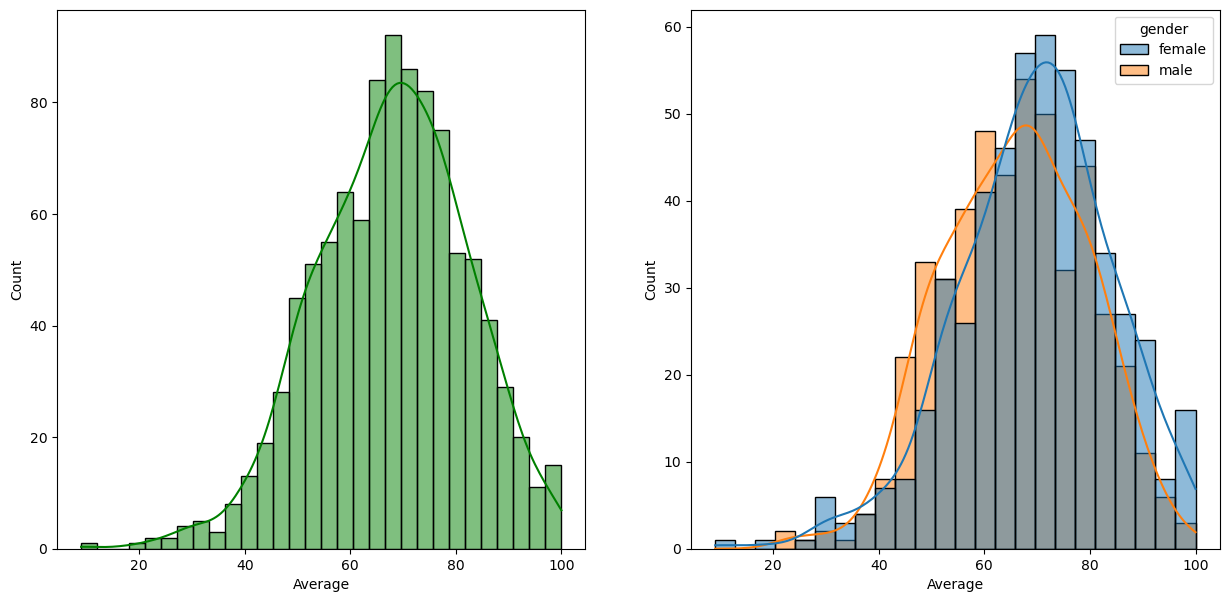

In [41]:
fig , axs = plt.subplots(1, 2 , figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde=True,hue='gender')
plt.show()